# Lab 4: Regresión lineal y gradiente descendente - SOLUCIÓN

## Problema 1-3: Datos lineales simples, función de coste y minimización

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from sklearn.linear_model import LinearRegression
import seaborn as sns

# 1. Construir DataFrame con datos lineales simples
np.random.seed(42)
X_simple = np.linspace(0, 10, 50)
y_simple = 2 + 3*X_simple + np.random.randn(50)*2

df_simple = pd.DataFrame({'X': X_simple, 'y': y_simple})
print("DataFrame con datos lineales simples:")
print(df_simple.head())
print(f"\nForma: {df_simple.shape}")

DataFrame con datos lineales simples:
          X         y
0  0.000000  2.993428
1  0.204082  2.335716
2  0.408163  4.519867
3  0.612245  6.882794
4  0.816327  3.980673

Forma: (50, 2)


### 2. Función de coste cuadrática

In [2]:
def cost_function(X, y, theta0, theta1):
    """
    Calcula la función de coste cuadrática para regresión lineal.
    
    J(θ0, θ1) = (1/2m) * Σ(h(x^(i)) - y^(i))^2
    donde h(x) = θ0 + θ1*x
    
    Parameters:
    -----------
    X : array-like
        Características de entrada
    y : array-like
        Valores objetivo
    theta0 : float
        Parámetro θ0 (intercepción)
    theta1 : float
        Parámetro θ1 (pendiente)
    
    Returns:
    --------
    J : float
        Valor de la función de coste
    """
    m = len(y)
    predictions = theta0 + theta1 * X
    errors = predictions - y
    J = (1/(2*m)) * np.sum(errors**2)
    return J

# Prueba
J_test = cost_function(X_simple, y_simple, 2, 3)
print(f"Costo para θ0=2, θ1=3: {J_test:.4f}")

Costo para θ0=2, θ1=3: 1.8103


### 3. Minimización con θ0=0, variando θ1

θ1 óptimo (con θ0=0): 3.1759
Costo mínimo: 2.2439


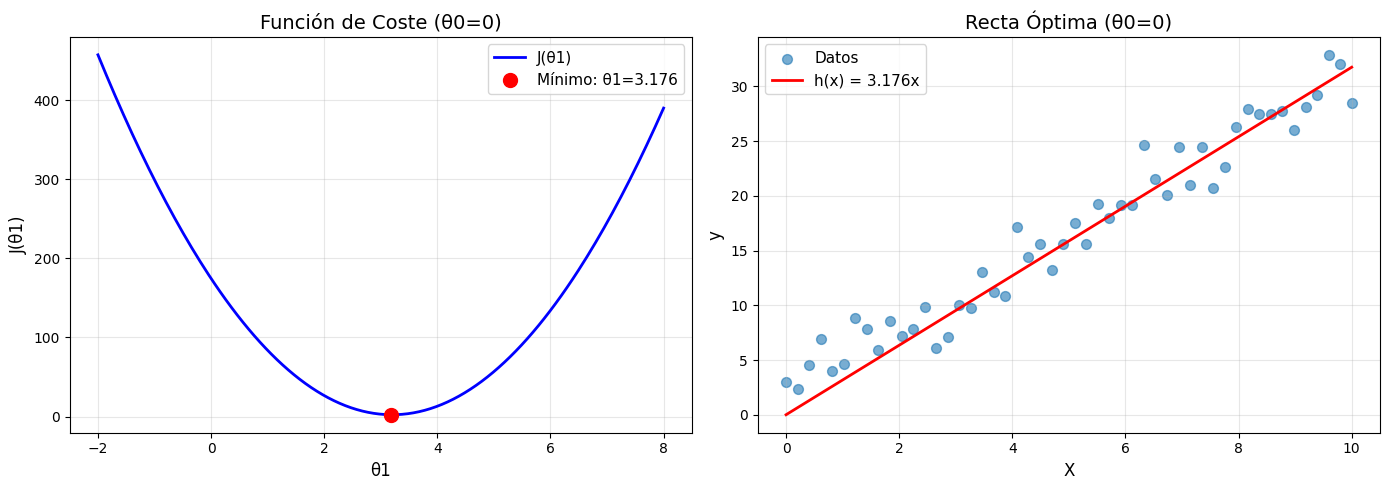

In [3]:
# Evaluar función de coste para diferentes valores de θ1 (con θ0=0)
theta1_values = np.linspace(-2, 8, 200)
J_values = [cost_function(X_simple, y_simple, 0, t1) for t1 in theta1_values]

# Encontrar el mínimo
min_idx = np.argmin(J_values)
theta1_opt = theta1_values[min_idx]
J_min = J_values[min_idx]

print(f"θ1 óptimo (con θ0=0): {theta1_opt:.4f}")
print(f"Costo mínimo: {J_min:.4f}")

# Graficar
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Gráfica de la función de coste
ax1.plot(theta1_values, J_values, 'b-', linewidth=2, label='J(θ1)')
ax1.plot(theta1_opt, J_min, 'ro', markersize=10, label=f'Mínimo: θ1={theta1_opt:.3f}')
ax1.set_xlabel('θ1', fontsize=12)
ax1.set_ylabel('J(θ1)', fontsize=12)
ax1.set_title('Función de Coste (θ0=0)', fontsize=14)
ax1.grid(True, alpha=0.3)
ax1.legend(fontsize=11)

# Gráfica de datos y recta óptima
ax2.scatter(X_simple, y_simple, alpha=0.6, s=50, label='Datos')
y_pred = theta1_opt * X_simple
ax2.plot(X_simple, y_pred, 'r-', linewidth=2, label=f'h(x) = {theta1_opt:.3f}x')
ax2.set_xlabel('X', fontsize=12)
ax2.set_ylabel('y', fontsize=12)
ax2.set_title('Recta Óptima (θ0=0)', fontsize=14)
ax2.grid(True, alpha=0.3)
ax2.legend(fontsize=11)

plt.tight_layout()
plt.show()

### 4. Superficie de coste variando θ0 y θ1

Mínimo global encontrado:
  θ0 óptimo: 2.2727
  θ1 óptimo: 2.8485
  J(θ0, θ1) mínimo: 1.6563


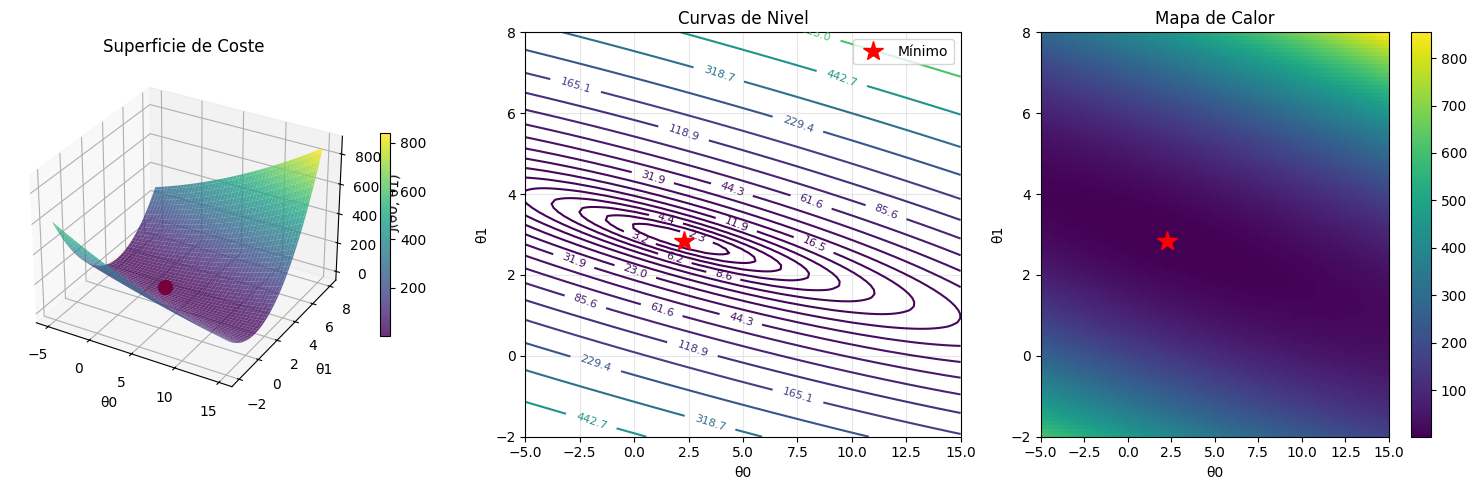

In [4]:
# Crear malla de valores para θ0 y θ1
theta0_range = np.linspace(-5, 15, 100)
theta1_range = np.linspace(-2, 8, 100)
Theta0, Theta1 = np.meshgrid(theta0_range, theta1_range)

# Calcular función de coste para cada combinación
J = np.zeros_like(Theta0)
for i in range(len(theta0_range)):
    for j in range(len(theta1_range)):
        J[j, i] = cost_function(X_simple, y_simple, Theta0[j, i], Theta1[j, i])

# Encontrar mínimo global
min_idx_global = np.unravel_index(np.argmin(J), J.shape)
theta0_opt_global = Theta0[min_idx_global]
theta1_opt_global = Theta1[min_idx_global]
J_min_global = J[min_idx_global]

print(f"Mínimo global encontrado:")
print(f"  θ0 óptimo: {theta0_opt_global:.4f}")
print(f"  θ1 óptimo: {theta1_opt_global:.4f}")
print(f"  J(θ0, θ1) mínimo: {J_min_global:.4f}")

# Visualización 3D
fig = plt.figure(figsize=(15, 5))

# Superficie 3D
ax1 = fig.add_subplot(131, projection='3d')
surf = ax1.plot_surface(Theta0, Theta1, J, cmap='viridis', alpha=0.8)
ax1.scatter([theta0_opt_global], [theta1_opt_global], [J_min_global], 
           color='red', s=100, label='Mínimo global')
ax1.set_xlabel('θ0', fontsize=10)
ax1.set_ylabel('θ1', fontsize=10)
ax1.set_zlabel('J(θ0, θ1)', fontsize=10)
ax1.set_title('Superficie de Coste', fontsize=12)
fig.colorbar(surf, ax=ax1, shrink=0.5)

# Curvas de nivel
ax2 = fig.add_subplot(132)
levels = np.logspace(np.log10(J.min()), np.log10(J.max()), 20)
contour = ax2.contour(Theta0, Theta1, J, levels=levels, cmap='viridis')
ax2.clabel(contour, inline=True, fontsize=8)
ax2.plot(theta0_opt_global, theta1_opt_global, 'r*', markersize=15, label='Mínimo')
ax2.set_xlabel('θ0', fontsize=10)
ax2.set_ylabel('θ1', fontsize=10)
ax2.set_title('Curvas de Nivel', fontsize=12)
ax2.legend()
ax2.grid(True, alpha=0.3)

# Mapa de calor
ax3 = fig.add_subplot(133)
im = ax3.imshow(J, cmap='viridis', aspect='auto', origin='lower',
                extent=[theta0_range.min(), theta0_range.max(), 
                       theta1_range.min(), theta1_range.max()])
ax3.plot(theta0_opt_global, theta1_opt_global, 'r*', markersize=15)
ax3.set_xlabel('θ0', fontsize=10)
ax3.set_ylabel('θ1', fontsize=10)
ax3.set_title('Mapa de Calor', fontsize=12)
fig.colorbar(im, ax=ax3)

plt.tight_layout()
plt.show()

### 5. Interpretación geométrica

La función de coste J(θ0, θ1) forma un paraboloide (superficie cóncava) en el espacio de parámetros. El mínimo global está en el fondo del paraboloide, donde los gradientes parciales son cero. La geometría indica que el problema es convexo y tiene un único mínimo global.

### 6. Datos con ruido

Datos limpios - θ1 óptimo: 3.2864
Datos con ruido - θ1 óptimo: 3.1960
Diferencia: 0.0905


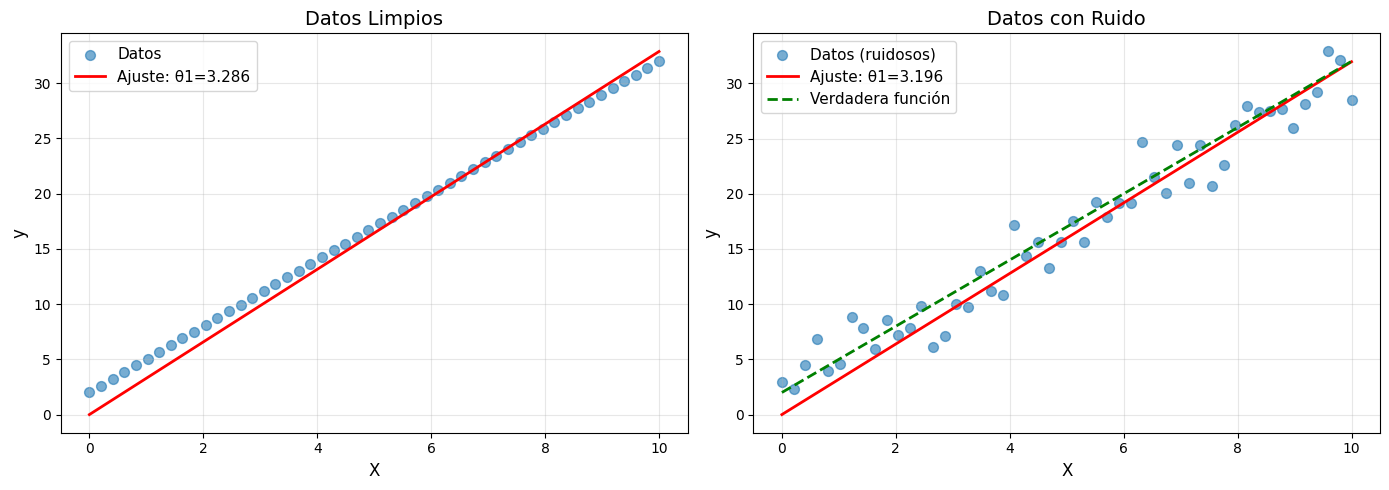

In [5]:
# Conjunto de datos original (sin ruido)
np.random.seed(42)
X_clean = np.linspace(0, 10, 50)
y_clean = 2 + 3*X_clean

# Conjunto de datos con ruido
y_noisy = y_clean + np.random.randn(50)*2

# Encontrar parámetros óptimos para ambos casos
# Para datos limpios
theta1_clean_values = np.linspace(0, 6, 200)
J_clean = [cost_function(X_clean, y_clean, 0, t1) for t1 in theta1_clean_values]
theta1_clean_opt = theta1_clean_values[np.argmin(J_clean)]

# Para datos con ruido
J_noisy = [cost_function(X_clean, y_noisy, 0, t1) for t1 in theta1_clean_values]
theta1_noisy_opt = theta1_clean_values[np.argmin(J_noisy)]

print(f"Datos limpios - θ1 óptimo: {theta1_clean_opt:.4f}")
print(f"Datos con ruido - θ1 óptimo: {theta1_noisy_opt:.4f}")
print(f"Diferencia: {abs(theta1_clean_opt - theta1_noisy_opt):.4f}")

# Visualizar
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Datos limpios
axes[0].scatter(X_clean, y_clean, alpha=0.6, s=50, label='Datos')
axes[0].plot(X_clean, theta1_clean_opt*X_clean, 'r-', linewidth=2, 
            label=f'Ajuste: θ1={theta1_clean_opt:.3f}')
axes[0].set_xlabel('X', fontsize=12)
axes[0].set_ylabel('y', fontsize=12)
axes[0].set_title('Datos Limpios', fontsize=14)
axes[0].grid(True, alpha=0.3)
axes[0].legend(fontsize=11)

# Datos con ruido
axes[1].scatter(X_clean, y_noisy, alpha=0.6, s=50, label='Datos (ruidosos)')
axes[1].plot(X_clean, theta1_noisy_opt*X_clean, 'r-', linewidth=2, 
            label=f'Ajuste: θ1={theta1_noisy_opt:.3f}')
axes[1].plot(X_clean, y_clean, 'g--', linewidth=2, label='Verdadera función')
axes[1].set_xlabel('X', fontsize=12)
axes[1].set_ylabel('y', fontsize=12)
axes[1].set_title('Datos con Ruido', fontsize=14)
axes[1].grid(True, alpha=0.3)
axes[1].legend(fontsize=11)

plt.tight_layout()
plt.show()

### 7. Efecto de valores atípicos

Datos sin outlier - θ1: 3.1960
Datos con outlier - θ1: 3.2261
Cambio debido al outlier: 0.0302


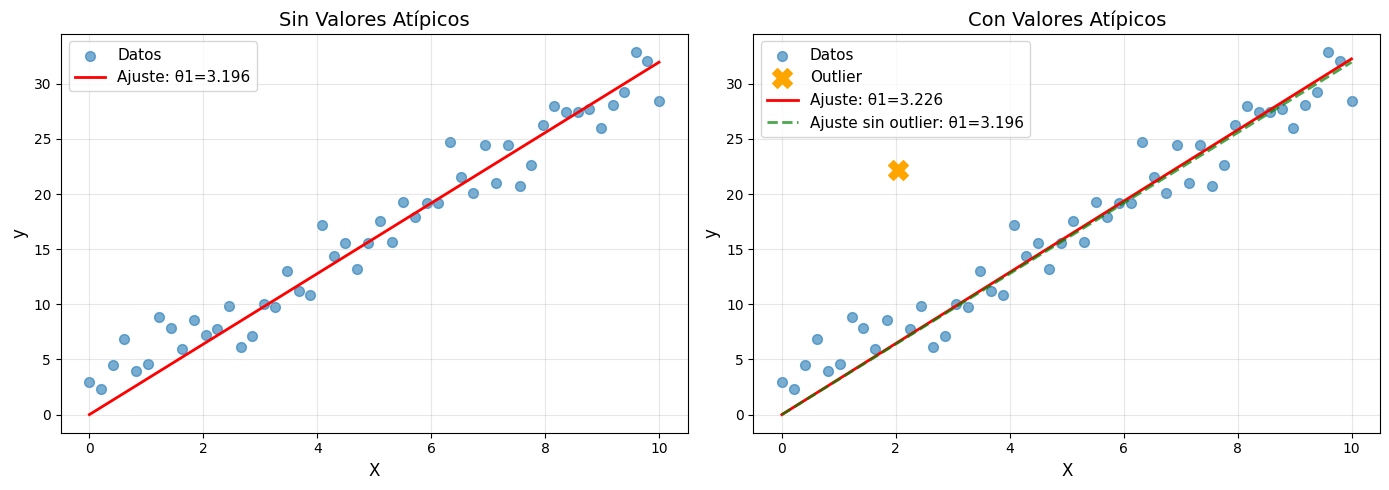

 Limitación: La función de coste cuadrática es sensible a outliers
    porque los errores grandes se amplifican al elevar al cuadrado.


In [14]:
# Crear conjunto con valor atípico
y_outlier = y_noisy.copy()
outlier_idx = 10
y_outlier[outlier_idx] = y_outlier[outlier_idx] + 15  # Añadir perturbación grande

# Encontrar parámetros óptimos
J_outlier = [cost_function(X_clean, y_outlier, 0, t1) for t1 in theta1_clean_values]
theta1_outlier_opt = theta1_clean_values[np.argmin(J_outlier)]

print(f"Datos sin outlier - θ1: {theta1_noisy_opt:.4f}")
print(f"Datos con outlier - θ1: {theta1_outlier_opt:.4f}")
print(f"Cambio debido al outlier: {abs(theta1_noisy_opt - theta1_outlier_opt):.4f}")

# Visualizar
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Sin outlier
axes[0].scatter(X_clean, y_noisy, alpha=0.6, s=50, label='Datos')
axes[0].plot(X_clean, theta1_noisy_opt*X_clean, 'r-', linewidth=2,
            label=f'Ajuste: θ1={theta1_noisy_opt:.3f}')
axes[0].set_xlabel('X', fontsize=12)
axes[0].set_ylabel('y', fontsize=12)
axes[0].set_title('Sin Valores Atípicos', fontsize=14)
axes[0].grid(True, alpha=0.3)
axes[0].legend(fontsize=11)

# Con outlier
axes[1].scatter(X_clean, y_outlier, alpha=0.6, s=50, label='Datos')
axes[1].scatter([X_clean[outlier_idx]], [y_outlier[outlier_idx]], 
               color='orange', s=200, marker='X', label='Outlier', zorder=5)
axes[1].plot(X_clean, theta1_outlier_opt*X_clean, 'r-', linewidth=2,
            label=f'Ajuste: θ1={theta1_outlier_opt:.3f}')
axes[1].plot(X_clean, theta1_noisy_opt*X_clean, 'g--', linewidth=2, alpha=0.7,
            label=f'Ajuste sin outlier: θ1={theta1_noisy_opt:.3f}')
axes[1].set_xlabel('X', fontsize=12)
axes[1].set_ylabel('y', fontsize=12)
axes[1].set_title('Con Valores Atípicos', fontsize=14)
axes[1].grid(True, alpha=0.3)
axes[1].legend(fontsize=11)

plt.tight_layout()
plt.show()

print(" Limitación: La función de coste cuadrática es sensible a outliers")
print("    porque los errores grandes se amplifican al elevar al cuadrado.")

### 8. Datos no lineales

Ajuste lineal óptimo para datos no lineales: θ1 = -0.0151


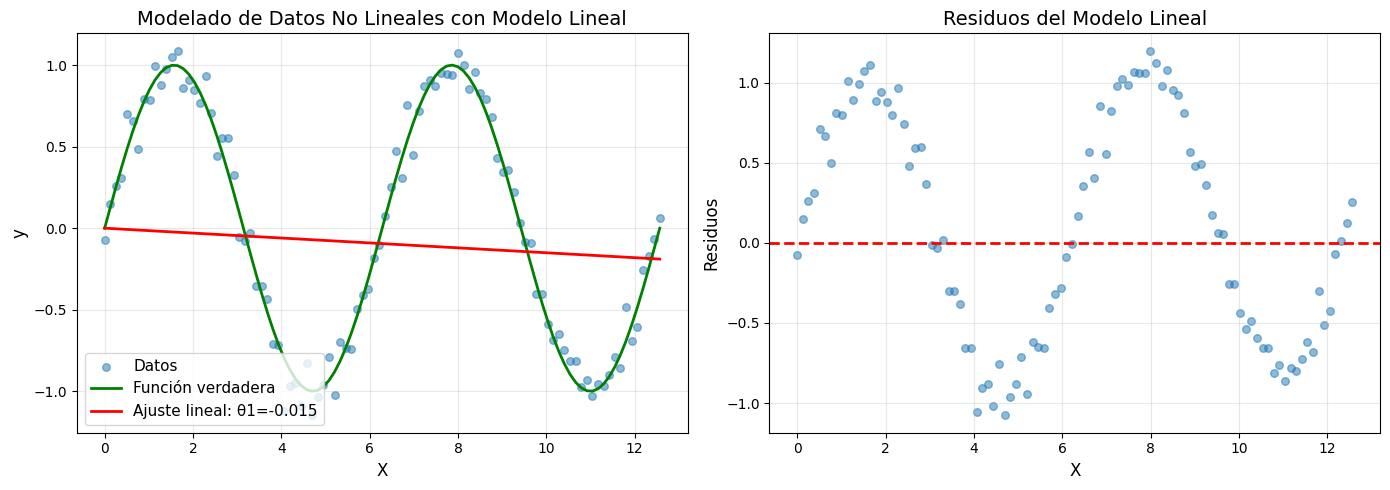

 Conclusión: Minimizar J(θ) no garantiza buen desempeño si el modelo
    es inadecuado para los datos. Aquí el sesgo del modelo es muy alto.


In [15]:
# Datos no lineales
X_nonlinear = np.linspace(0, 4*np.pi, 100)
y_nonlinear = np.sin(X_nonlinear) + np.random.randn(100)*0.1

# Ajuste lineal
theta1_nl_values = np.linspace(-1, 1, 200)
J_nl = [cost_function(X_nonlinear, y_nonlinear, 0, t1) for t1 in theta1_nl_values]
theta1_nl_opt = theta1_nl_values[np.argmin(J_nl)]

print(f"Ajuste lineal óptimo para datos no lineales: θ1 = {theta1_nl_opt:.4f}")

# Visualizar
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Datos y ajuste
axes[0].scatter(X_nonlinear, y_nonlinear, alpha=0.5, s=30, label='Datos')
axes[0].plot(X_nonlinear, np.sin(X_nonlinear), 'g-', linewidth=2, label='Función verdadera')
axes[0].plot(X_nonlinear, theta1_nl_opt*X_nonlinear, 'r-', linewidth=2,
            label=f'Ajuste lineal: θ1={theta1_nl_opt:.3f}')
axes[0].set_xlabel('X', fontsize=12)
axes[0].set_ylabel('y', fontsize=12)
axes[0].set_title('Modelado de Datos No Lineales con Modelo Lineal', fontsize=14)
axes[0].grid(True, alpha=0.3)
axes[0].legend(fontsize=11)

# Residuos
y_pred_nl = theta1_nl_opt * X_nonlinear
residuos = y_nonlinear - y_pred_nl
axes[1].scatter(X_nonlinear, residuos, alpha=0.5, s=30)
axes[1].axhline(y=0, color='r', linestyle='--', linewidth=2)
axes[1].set_xlabel('X', fontsize=12)
axes[1].set_ylabel('Residuos', fontsize=12)
axes[1].set_title('Residuos del Modelo Lineal', fontsize=14)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(" Conclusión: Minimizar J(θ) no garantiza buen desempeño si el modelo")
print("    es inadecuado para los datos. Aquí el sesgo del modelo es muy alto.")

### 9. Expresión teórica de la función de coste

**Para un parámetro (θ0=0):**

$$J(\theta_1) = \frac{1}{2m}\sum_{i=1}^{m}(\theta_1 x^{(i)} - y^{(i)})^2$$

Expandiendo:
$$J(\theta_1) = \frac{1}{2m}\left[\theta_1^2 \sum (x^{(i)})^2 - 2\theta_1\sum x^{(i)}y^{(i)} + \sum (y^{(i)})^2\right]$$

El mínimo se encuentra en:
$$\theta_1^* = \frac{\sum_{i=1}^{m} x^{(i)}y^{(i)}}{\sum_{i=1}^{m} (x^{(i)})^2}$$

**Para dos parámetros:**

$$J(\theta_0, \theta_1) = \frac{1}{2m}\sum_{i=1}^{m}(\theta_0 + \theta_1 x^{(i)} - y^{(i)})^2$$

El mínimo se encuentra donde:
$$\frac{\partial J}{\partial \theta_0} = 0, \quad \frac{\partial J}{\partial \theta_1} = 0$$

Lo que da:
$$\theta_0^* = \bar{y} - \theta_1^*\bar{x}$$
$$\theta_1^* = \frac{\sum_{i=1}^{m} (x^{(i)} - \bar{x})(y^{(i)} - \bar{y})}{\sum_{i=1}^{m} (x^{(i)} - \bar{x})^2}$$

In [8]:
# Verificar la expresión teórica
# Para θ0=0
theta1_theoretical = np.sum(X_simple * y_simple) / np.sum(X_simple**2)
print(f"θ1 teórico (θ0=0): {theta1_theoretical:.4f}")
print(f"θ1 encontrado numéricamente: {theta1_opt:.4f}")
print(f"Diferencia: {abs(theta1_theoretical - theta1_opt):.6f}")

# Para θ0 y θ1 (usando ecuaciones normales)
X_with_ones = np.column_stack([np.ones_like(X_simple), X_simple])
theta_normal = np.linalg.inv(X_with_ones.T @ X_with_ones) @ X_with_ones.T @ y_simple
theta0_normal, theta1_normal = theta_normal

print(f"\nUsando ecuaciones normales:")
print(f"  θ0 teórico: {theta0_normal:.4f}")
print(f"  θ1 teórico: {theta1_normal:.4f}")
print(f"\nEncontrados numéricamente en malla:")
print(f"  θ0: {theta0_opt_global:.4f}")
print(f"  θ1: {theta1_opt_global:.4f}")

θ1 teórico (θ0=0): 3.2001
θ1 encontrado numéricamente: 3.1759
Diferencia: 0.024261

Usando ecuaciones normales:
  θ0 teórico: 2.1289
  θ1 teórico: 2.8840

Encontrados numéricamente en malla:
  θ0: 2.2727
  θ1: 2.8485


## Problema 10: Algoritmo de gradiente descendente para función 1D

Convergencia alcanzada en iteración 332

α = 0.01:
  x óptimo: 3.995112
  f(x) mínimo: 0.000024
  Iteraciones: 332
Convergencia alcanzada en iteración 42

α = 0.1:
  x óptimo: 3.999660
  f(x) mínimo: 0.000000
  Iteraciones: 42
Convergencia alcanzada en iteración 20

α = 0.2:
  x óptimo: 3.999854
  f(x) mínimo: 0.000000
  Iteraciones: 20


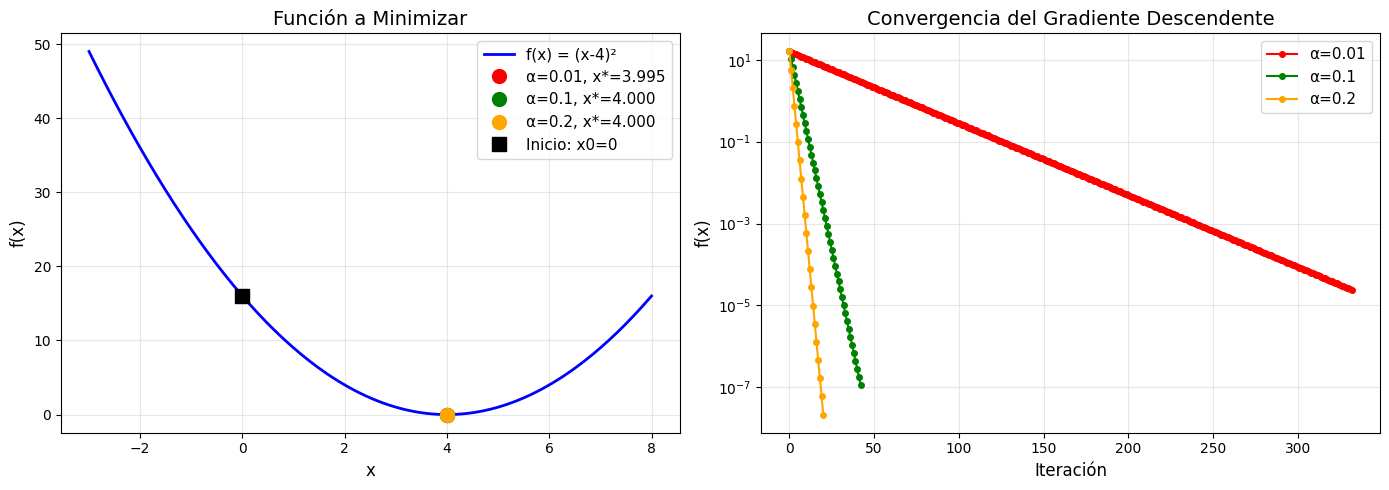

In [9]:
def gradient_descent_1d(f, df, x0, alpha, epsilon=1e-4, max_iter=1000):
    """
    Algoritmo de gradiente descendente para optimizar una función 1D.
    
    Parameters:
    -----------
    f : function
        Función a minimizar
    df : function
        Derivada de f
    x0 : float
        Valor inicial
    alpha : float
        Tasa de aprendizaje
    epsilon : float
        Tolerancia para convergencia
    max_iter : int
        Número máximo de iteraciones
    
    Returns:
    --------
    x : float
        Valor óptimo encontrado
    history : list
        Historial de valores x durante la optimización
    """
    x = x0
    history = [x]
    
    for iteration in range(max_iter):
        gradient = df(x)
        x_new = x - alpha * gradient
        
        # Criterio de convergencia
        if abs(x_new - x) < epsilon:
            history.append(x_new)
            print(f"Convergencia alcanzada en iteración {iteration+1}")
            return x_new, history
        
        x = x_new
        history.append(x)
    
    print(f"Máximo de iteraciones alcanzado: {max_iter}")
    return x, history

# Función a minimizar: f(x) = (x-4)^2
def f(x):
    return (x - 4)**2

def df(x):
    return 2*(x - 4)

# Probar con diferentes tasas de aprendizaje
alphas = [0.01, 0.1, 0.2]
x0 = 0
epsilon = 1e-4

results = {}
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for alpha in alphas:
    x_opt, history = gradient_descent_1d(f, df, x0, alpha, epsilon)
    results[alpha] = {'x_opt': x_opt, 'history': history}
    print(f"\nα = {alpha}:")
    print(f"  x óptimo: {x_opt:.6f}")
    print(f"  f(x) mínimo: {f(x_opt):.6f}")
    print(f"  Iteraciones: {len(history)-1}")

# Visualizar función
x_range = np.linspace(-3, 8, 200)
y_range = f(x_range)

ax1 = axes[0]
ax1.plot(x_range, y_range, 'b-', linewidth=2, label='f(x) = (x-4)²')
colors = ['red', 'green', 'orange']
for alpha, color in zip(alphas, colors):
    x_opt = results[alpha]['x_opt']
    ax1.plot(x_opt, f(x_opt), 'o', color=color, markersize=10, label=f'α={alpha}, x*={x_opt:.3f}')
ax1.plot(x0, f(x0), 's', color='black', markersize=10, label=f'Inicio: x0={x0}')
ax1.set_xlabel('x', fontsize=12)
ax1.set_ylabel('f(x)', fontsize=12)
ax1.set_title('Función a Minimizar', fontsize=14)
ax1.grid(True, alpha=0.3)
ax1.legend(fontsize=11)

# Visualizar convergencia
ax2 = axes[1]
for alpha, color in zip(alphas, colors):
    history = results[alpha]['history']
    iterations = range(len(history))
    f_values = [f(x) for x in history]
    ax2.plot(iterations, f_values, 'o-', color=color, label=f'α={alpha}', markersize=4)
ax2.set_xlabel('Iteración', fontsize=12)
ax2.set_ylabel('f(x)', fontsize=12)
ax2.set_title('Convergencia del Gradiente Descendente', fontsize=14)
ax2.set_yscale('log')
ax2.grid(True, alpha=0.3, which='both')
ax2.legend(fontsize=11)

plt.tight_layout()
plt.show()

## Problema 11: Gradiente descendente 2D

Ejecutando gradiente descendente 2D...
Convergencia en iteración 479

Mínimo encontrado:
  x* = 0.183291
  y* = 1.543566
  F(x*, y*) = -0.649862
  Iteraciones: 479


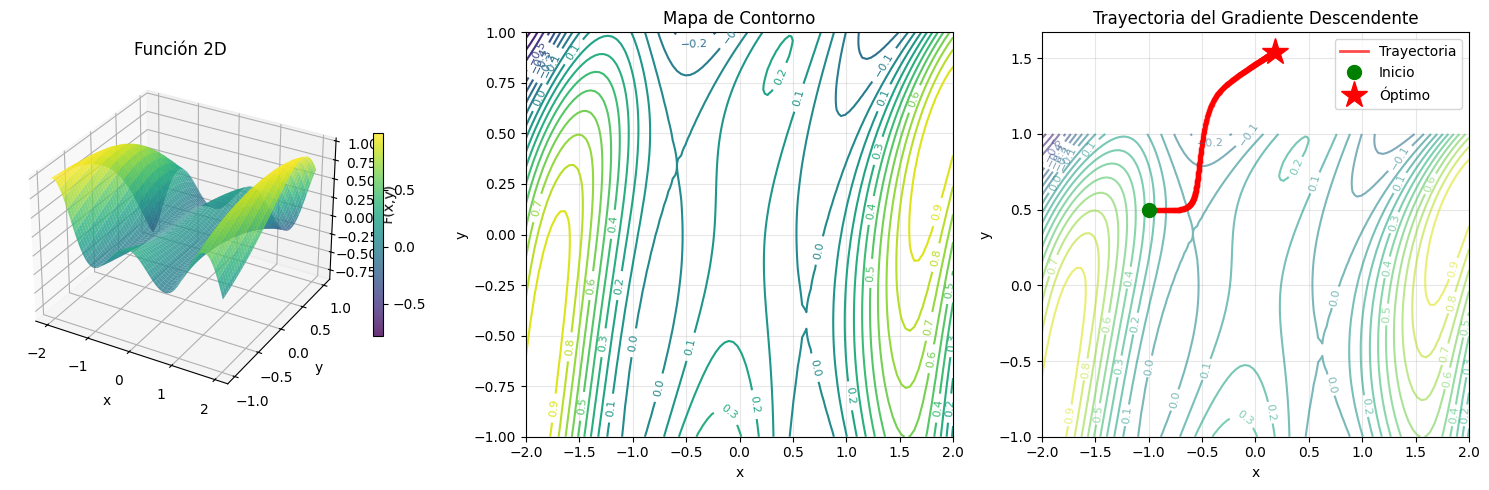

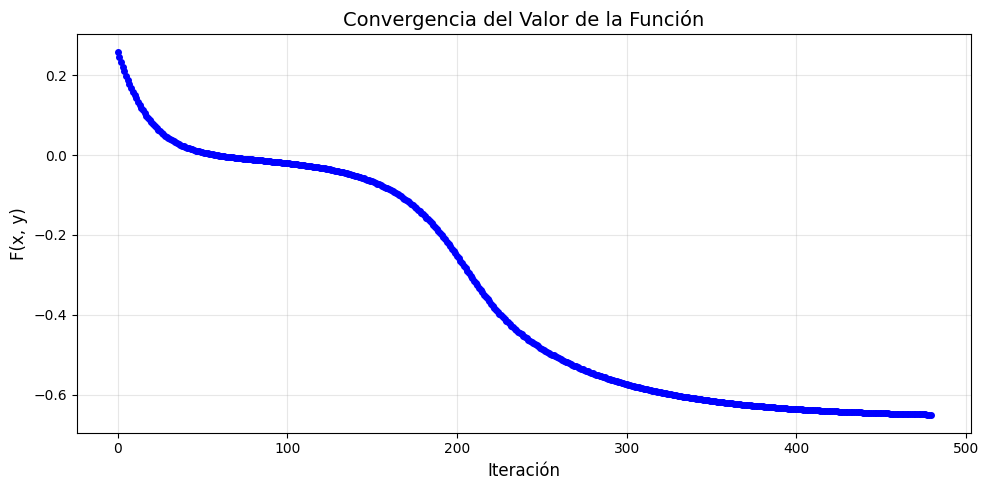

In [10]:
# Función 2D: F(x,y) = sin(0.5*x^2 - 0.25*y^2 + 3)*cos(2*x + 1 - e^y)
def F(x, y):
    return np.sin(0.5*x**2 - 0.25*y**2 + 3) * np.cos(2*x + 1 - np.exp(y))

# Gradientes parciales (calculados numéricamente)
def grad_F(x, y, h=1e-5):
    dF_dx = (F(x+h, y) - F(x-h, y)) / (2*h)
    dF_dy = (F(x, y+h) - F(x, y-h)) / (2*h)
    return np.array([dF_dx, dF_dy])

# Gráfica 3D
x_range = np.linspace(-2, 2, 100)
y_range = np.linspace(-1, 1, 100)
X_grid, Y_grid = np.meshgrid(x_range, y_range)
Z_grid = F(X_grid, Y_grid)

fig = plt.figure(figsize=(15, 5))

# Superficie 3D
ax1 = fig.add_subplot(131, projection='3d')
surf = ax1.plot_surface(X_grid, Y_grid, Z_grid, cmap='viridis', alpha=0.8)
ax1.set_xlabel('x', fontsize=10)
ax1.set_ylabel('y', fontsize=10)
ax1.set_zlabel('F(x,y)', fontsize=10)
ax1.set_title('Función 2D', fontsize=12)
fig.colorbar(surf, ax=ax1, shrink=0.5)

# Mapa de contorno
ax2 = fig.add_subplot(132)
contour = ax2.contour(X_grid, Y_grid, Z_grid, levels=20, cmap='viridis')
ax2.clabel(contour, inline=True, fontsize=8)
ax2.set_xlabel('x', fontsize=10)
ax2.set_ylabel('y', fontsize=10)
ax2.set_title('Mapa de Contorno', fontsize=12)
ax2.grid(True, alpha=0.3)

# Gradiente descendente
print("Ejecutando gradiente descendente 2D...")
x_init = np.array([-1.0, 0.5])
alpha = 0.01
epsilon = 1e-3
max_iter = 1000

x_current = x_init.copy()
history = [x_current.copy()]
f_history = [F(x_current[0], x_current[1])]

for iteration in range(max_iter):
    gradient = grad_F(x_current[0], x_current[1])
    x_new = x_current - alpha * gradient
    
    if np.linalg.norm(x_new - x_current) < epsilon:
        print(f"Convergencia en iteración {iteration+1}")
        history.append(x_new)
        f_history.append(F(x_new[0], x_new[1]))
        break
    
    x_current = x_new
    history.append(x_current.copy())
    f_history.append(F(x_current[0], x_current[1]))

history = np.array(history)

x_opt, y_opt = x_current
print(f"\nMínimo encontrado:")
print(f"  x* = {x_opt:.6f}")
print(f"  y* = {y_opt:.6f}")
print(f"  F(x*, y*) = {F(x_opt, y_opt):.6f}")
print(f"  Iteraciones: {len(history)-1}")

# Visualizar trayectoria
ax3 = fig.add_subplot(133)
contour = ax3.contour(X_grid, Y_grid, Z_grid, levels=20, cmap='viridis', alpha=0.6)
ax3.clabel(contour, inline=True, fontsize=8)
ax3.plot(history[:, 0], history[:, 1], 'r-', linewidth=2, alpha=0.7, label='Trayectoria')
ax3.plot(history[:, 0], history[:, 1], 'ro', markersize=3, alpha=0.5)
ax3.plot(x_init[0], x_init[1], 'go', markersize=10, label='Inicio')
ax3.plot(x_opt, y_opt, 'r*', markersize=20, label='Óptimo')
ax3.set_xlabel('x', fontsize=10)
ax3.set_ylabel('y', fontsize=10)
ax3.set_title('Trayectoria del Gradiente Descendente', fontsize=12)
ax3.legend(fontsize=10)
ax3.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Gráfica de convergencia
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(f_history, 'b-o', markersize=4)
ax.set_xlabel('Iteración', fontsize=12)
ax.set_ylabel('F(x, y)', fontsize=12)
ax.set_title('Convergencia del Valor de la Función', fontsize=14)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Problema 12: Regresión lineal con datos reales y comparación con sklearn

Convergencia en iteración 124
Comparación de métodos:

Gradiente Descendente:
  θ0 = 0.208564
  θ1 = 0.203660

Scikit-learn:
  θ0 = 0.208557
  θ1 = 0.203673

Ecuaciones Normales:
  θ0 = 0.208557
  θ1 = 0.203673


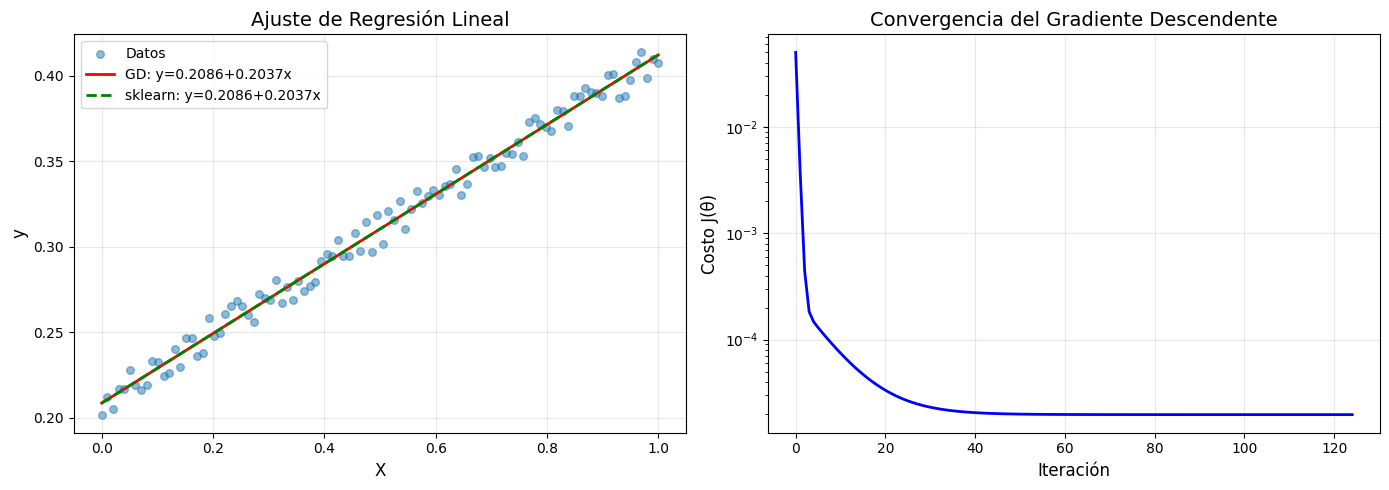

 Los tres métodos producen parámetros equivalentes.
  Diferencia GD vs sklearn: θ0=7.00e-06, θ1=1.31e-05


In [16]:
# Datos del problema
X_data = np.linspace(0, 1, 100)
y_data = 0.2 + 0.2*X_data + 0.02*np.random.random(100)

# Función para ejecutar gradiente descendente en regresión lineal
def gradient_descent_linear_regression(X, y, alpha=0.01, epsilon=1e-6, max_iter=10000):
    """
    Gradiente descendente para regresión lineal.
    
    Parameters:
    -----------
    X : array-like
        Características de entrada
    y : array-like
        Valores objetivo
    alpha : float
        Tasa de aprendizaje
    epsilon : float
        Tolerancia para convergencia
    max_iter : int
        Máximo número de iteraciones
    
    Returns:
    --------
    theta0, theta1 : float
        Parámetros óptimos
    history : list
        Historial de costos
    """
    m = len(y)
    theta0, theta1 = 0.0, 0.0
    history = []
    
    for iteration in range(max_iter):
        # Predicciones
        y_pred = theta0 + theta1 * X
        
        # Costo
        J = (1/(2*m)) * np.sum((y_pred - y)**2)
        history.append(J)
        
        # Gradientes
        dJ_dtheta0 = (1/m) * np.sum(y_pred - y)
        dJ_dtheta1 = (1/m) * np.sum((y_pred - y) * X)
        
        # Actualizar parámetros
        theta0_new = theta0 - alpha * dJ_dtheta0
        theta1_new = theta1 - alpha * dJ_dtheta1
        
        # Convergencia
        if abs(theta0_new - theta0) < epsilon and abs(theta1_new - theta1) < epsilon:
            theta0, theta1 = theta0_new, theta1_new
            history.append((1/(2*m)) * np.sum((theta0 + theta1*X - y)**2))
            print(f"Convergencia en iteración {iteration+1}")
            break
        
        theta0, theta1 = theta0_new, theta1_new
    
    return theta0, theta1, history

# Regresión con gradiente descendente
theta0_gd, theta1_gd, history_gd = gradient_descent_linear_regression(X_data, y_data, alpha=1.0)

# Regresión con sklearn
X_sklearn = X_data.reshape(-1, 1)
model_sklearn = LinearRegression()
model_sklearn.fit(X_sklearn, y_data)
theta0_sklearn = model_sklearn.intercept_
theta1_sklearn = model_sklearn.coef_[0]

# Ecuaciones normales
X_design = np.column_stack([np.ones_like(X_data), X_data])
theta_normal = np.linalg.inv(X_design.T @ X_design) @ X_design.T @ y_data
theta0_normal, theta1_normal = theta_normal

print("Comparación de métodos:")
print(f"\nGradiente Descendente:")
print(f"  θ0 = {theta0_gd:.6f}")
print(f"  θ1 = {theta1_gd:.6f}")

print(f"\nScikit-learn:")
print(f"  θ0 = {theta0_sklearn:.6f}")
print(f"  θ1 = {theta1_sklearn:.6f}")

print(f"\nEcuaciones Normales:")
print(f"  θ0 = {theta0_normal:.6f}")
print(f"  θ1 = {theta1_normal:.6f}")

# Visualizar
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Datos y ajustes
ax1 = axes[0]
ax1.scatter(X_data, y_data, alpha=0.5, s=30, label='Datos')
ax1.plot(X_data, theta0_gd + theta1_gd*X_data, 'r-', linewidth=2, label=f'GD: y={theta0_gd:.4f}+{theta1_gd:.4f}x')
ax1.plot(X_data, theta0_sklearn + theta1_sklearn*X_data, 'g--', linewidth=2, label=f'sklearn: y={theta0_sklearn:.4f}+{theta1_sklearn:.4f}x')
ax1.set_xlabel('X', fontsize=12)
ax1.set_ylabel('y', fontsize=12)
ax1.set_title('Ajuste de Regresión Lineal', fontsize=14)
ax1.grid(True, alpha=0.3)
ax1.legend(fontsize=10)

# Convergencia
ax2 = axes[1]
ax2.plot(history_gd, 'b-', linewidth=2)
ax2.set_xlabel('Iteración', fontsize=12)
ax2.set_ylabel('Costo J(θ)', fontsize=12)
ax2.set_title('Convergencia del Gradiente Descendente', fontsize=14)
ax2.grid(True, alpha=0.3)
ax2.set_yscale('log')

plt.tight_layout()
plt.show()

print(f" Los tres métodos producen parámetros equivalentes.")
print(f"  Diferencia GD vs sklearn: θ0={abs(theta0_gd-theta0_sklearn):.2e}, θ1={abs(theta1_gd-theta1_sklearn):.2e}")

## Problema 13: Librería de Python para Regresión Lineal

A continuación se presenta una librería empaquetada para regresión lineal usando gradiente descendente.

In [12]:
# Código para la librería
library_code = '''
"""linear_regression_lib.py

Librería para realizar regresión lineal mediante función de coste y gradiente descendente.
Autores: Estudiantes FCII
Fecha: 2026
"""

import numpy as np

class LinearRegressionGD:
    """Regresión lineal mediante gradiente descendente.
    
    Attributes:
        theta0 (float): Parámetro de intercepción (bias)
        theta1 (float): Parámetro de pendiente
        history (list): Historial de costos durante el entrenamiento
    """
    
    def __init__(self, alpha=0.01, epsilon=1e-6, max_iter=10000):
        """Inicializar el modelo.
        
        Args:
            alpha (float): Tasa de aprendizaje (learning rate)
            epsilon (float): Tolerancia para convergencia
            max_iter (int): Número máximo de iteraciones
        """
        self.alpha = alpha
        self.epsilon = epsilon
        self.max_iter = max_iter
        self.theta0 = 0.0
        self.theta1 = 0.0
        self.history = []
    
    def hypothesis(self, X):
        """Calcula la hipótesis lineal.
        
        Args:
            X (array-like): Valores de entrada
        
        Returns:
            array-like: Predicciones h(x) = θ0 + θ1*x
        """
        return self.theta0 + self.theta1 * X
    
    def cost_function(self, X, y):
        """Calcula la función de coste.
        
        Args:
            X (array-like): Características de entrada
            y (array-like): Valores objetivo
        
        Returns:
            float: Costo J(θ0, θ1)
        """
        m = len(y)
        predictions = self.hypothesis(X)
        errors = predictions - y
        J = (1/(2*m)) * np.sum(errors**2)
        return J
    
    def fit(self, X, y, verbose=True):
        """Entrena el modelo usando gradiente descendente.
        
        Args:
            X (array-like): Características de entrada de entrenamiento
            y (array-like): Valores objetivo de entrenamiento
            verbose (bool): Si imprimir el progreso
        
        Returns:
            self: Retorna el objeto para encadenamiento
        """
        m = len(y)
        self.history = []
        
        for iteration in range(self.max_iter):
            # Predicciones
            y_pred = self.hypothesis(X)
            
            # Costo
            J = self.cost_function(X, y)
            self.history.append(J)
            
            # Gradientes parciales
            dJ_dtheta0 = (1/m) * np.sum(y_pred - y)
            dJ_dtheta1 = (1/m) * np.sum((y_pred - y) * X)
            
            # Actualizar parámetros
            theta0_new = self.theta0 - self.alpha * dJ_dtheta0
            theta1_new = self.theta1 - self.alpha * dJ_dtheta1
            
            # Verificar convergencia
            if abs(theta0_new - self.theta0) < self.epsilon and \
               abs(theta1_new - self.theta1) < self.epsilon:
                self.theta0, self.theta1 = theta0_new, theta1_new
                if verbose:
                    print(f"Convergencia alcanzada en iteración {iteration+1}")
                break
            
            self.theta0, self.theta1 = theta0_new, theta1_new
        
        if verbose:
            print(f"Entrenamiento completado")
            print(f"θ0 = {self.theta0:.6f}, θ1 = {self.theta1:.6f}")
        
        return self
    
    def predict(self, X):
        """Realiza predicciones.
        
        Args:
            X (array-like): Características de entrada
        
        Returns:
            array-like: Predicciones
        """
        return self.hypothesis(X)
    
    def score(self, X, y):
        """Calcula el coeficiente de determinación R².
        
        Args:
            X (array-like): Características
            y (array-like): Valores objetivo
        
        Returns:
            float: Puntuación R² (0 a 1)
        """
        y_pred = self.predict(X)
        ss_res = np.sum((y - y_pred)**2)
        ss_tot = np.sum((y - np.mean(y))**2)
        r2 = 1 - (ss_res / ss_tot)
        return r2
'''

print("Código de la librería (linear_regression_lib.py):")
print("="*60)
print(library_code)
print("="*60)

Código de la librería (linear_regression_lib.py):

"""linear_regression_lib.py

Librería para realizar regresión lineal mediante función de coste y gradiente descendente.
Autores: Estudiantes FCII
Fecha: 2026
"""

import numpy as np

class LinearRegressionGD:
    """Regresión lineal mediante gradiente descendente.

    Attributes:
        theta0 (float): Parámetro de intercepción (bias)
        theta1 (float): Parámetro de pendiente
        history (list): Historial de costos durante el entrenamiento
    """

    def __init__(self, alpha=0.01, epsilon=1e-6, max_iter=10000):
        """Inicializar el modelo.

        Args:
            alpha (float): Tasa de aprendizaje (learning rate)
            epsilon (float): Tolerancia para convergencia
            max_iter (int): Número máximo de iteraciones
        """
        self.alpha = alpha
        self.epsilon = epsilon
        self.max_iter = max_iter
        self.theta0 = 0.0
        self.theta1 = 0.0
        self.history = []

    def hy

### Ejemplo de uso de la librería

Ejemplo de uso de la librería:
 Crear el modelo
model = LinearRegressionGD(alpha=1.0)
 Entrenar el modelo
model.fit(X_data, y_data)
Convergencia en iteración 124
θ0 = 0.208564, θ1 = 0.203660
 Hacer predicciones
Primeras 5 predicciones: [0.20856413 0.21062131 0.21267848 0.21473566 0.21679283]
 Evaluar el modelo
R² score: 0.988930


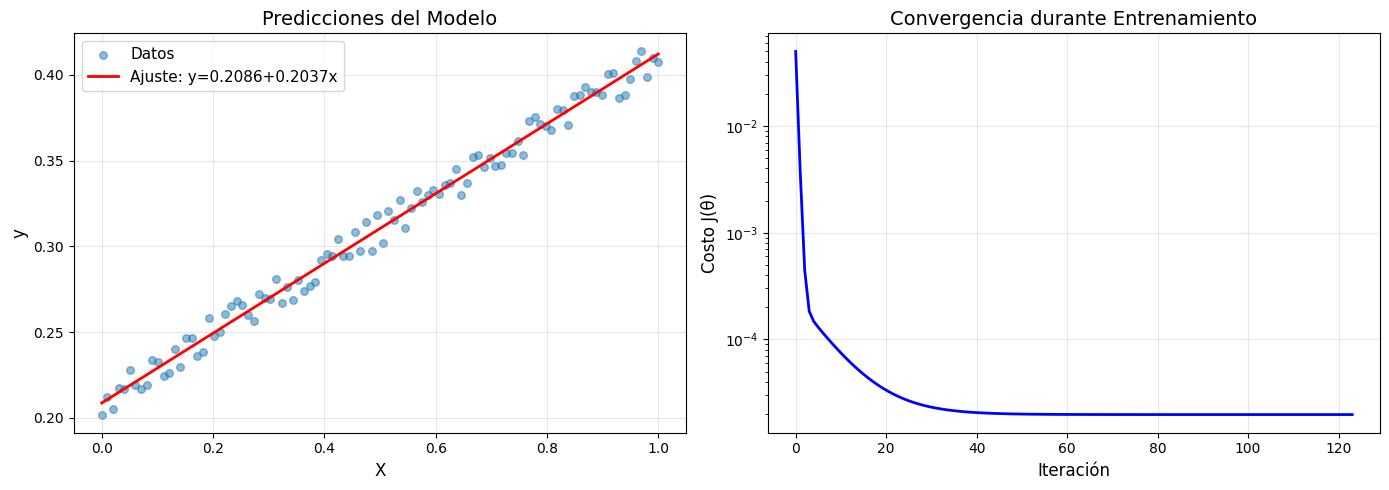

In [17]:
# Implementar la clase directamente en este notebook
class LinearRegressionGD:
    """Regresión lineal mediante gradiente descendente."""
    
    def __init__(self, alpha=0.01, epsilon=1e-6, max_iter=10000):
        self.alpha = alpha
        self.epsilon = epsilon
        self.max_iter = max_iter
        self.theta0 = 0.0
        self.theta1 = 0.0
        self.history = []
    
    def hypothesis(self, X):
        return self.theta0 + self.theta1 * X
    
    def cost_function(self, X, y):
        m = len(y)
        predictions = self.hypothesis(X)
        errors = predictions - y
        J = (1/(2*m)) * np.sum(errors**2)
        return J
    
    def fit(self, X, y, verbose=True):
        m = len(y)
        self.history = []
        
        for iteration in range(self.max_iter):
            y_pred = self.hypothesis(X)
            J = self.cost_function(X, y)
            self.history.append(J)
            
            dJ_dtheta0 = (1/m) * np.sum(y_pred - y)
            dJ_dtheta1 = (1/m) * np.sum((y_pred - y) * X)
            
            theta0_new = self.theta0 - self.alpha * dJ_dtheta0
            theta1_new = self.theta1 - self.alpha * dJ_dtheta1
            
            if abs(theta0_new - self.theta0) < self.epsilon and \
               abs(theta1_new - self.theta1) < self.epsilon:
                self.theta0, self.theta1 = theta0_new, theta1_new
                if verbose:
                    print(f"Convergencia en iteración {iteration+1}")
                break
            
            self.theta0, self.theta1 = theta0_new, theta1_new
        
        if verbose:
            print(f"θ0 = {self.theta0:.6f}, θ1 = {self.theta1:.6f}")
        
        return self
    
    def predict(self, X):
        return self.hypothesis(X)
    
    def score(self, X, y):
        y_pred = self.predict(X)
        ss_res = np.sum((y - y_pred)**2)
        ss_tot = np.sum((y - np.mean(y))**2)
        r2 = 1 - (ss_res / ss_tot)
        return r2

# Ejemplo de uso
print("Ejemplo de uso de la librería:")
print(" Crear el modelo")
print("model = LinearRegressionGD(alpha=1.0)")
model = LinearRegressionGD(alpha=1.0)

print(" Entrenar el modelo")
print("model.fit(X_data, y_data)")
model.fit(X_data, y_data)

print(" Hacer predicciones")
y_pred = model.predict(X_data)
print(f"Primeras 5 predicciones: {y_pred[:5]}")

print(" Evaluar el modelo")
r2 = model.score(X_data, y_data)
print(f"R² score: {r2:.6f}")

# Visualizar
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Predicciones
axes[0].scatter(X_data, y_data, alpha=0.5, s=30, label='Datos')
axes[0].plot(X_data, y_pred, 'r-', linewidth=2, 
            label=f'Ajuste: y={model.theta0:.4f}+{model.theta1:.4f}x')
axes[0].set_xlabel('X', fontsize=12)
axes[0].set_ylabel('y', fontsize=12)
axes[0].set_title('Predicciones del Modelo', fontsize=14)
axes[0].grid(True, alpha=0.3)
axes[0].legend(fontsize=11)

# Convergencia
axes[1].plot(model.history, 'b-', linewidth=2)
axes[1].set_xlabel('Iteración', fontsize=12)
axes[1].set_ylabel('Costo J(θ)', fontsize=12)
axes[1].set_title('Convergencia durante Entrenamiento', fontsize=14)
axes[1].grid(True, alpha=0.3)
axes[1].set_yscale('log')

plt.tight_layout()
plt.show()

### Instrucciones de instalación

**Archivo README.md:**

```markdown
 LinearRegressionGD - Librería de Regresión Lineal

 Descripción

Librería para realizar regresión lineal usando función de coste cuadrática y optimización por gradiente descendente.

 Instalación

```bash
pip install linear-regression-gd
```

 Requisitos

- NumPy
- Python 3.7+

 Uso

 Ejemplo básico

```python
import numpy as np
from linear_regression_lib import LinearRegressionGD

 Crear datos de entrenamiento
X = np.linspace(0, 1, 100)
y = 0.2 + 0.2*X + 0.02*np.random.random(100)

 Crear y entrenar el modelo
model = LinearRegressionGD(alpha=1.0)
model.fit(X, y)

 Hacer predicciones
y_pred = model.predict(X)

 Evaluar el modelo
r2 = model.score(X, y)
print(f"R² = {r2:.4f}")
```

 API

`LinearRegressionGD(alpha=0.01, epsilon=1e-6, max_iter=10000)`

**Parámetros:**
- `alpha` (float): Tasa de aprendizaje
- `epsilon` (float): Tolerancia para convergencia  
- `max_iter` (int): Número máximo de iteraciones

 Métodos

- `fit(X, y, verbose=True)`: Entrena el modelo
- `predict(X)`: Realiza predicciones
- `score(X, y)`: Calcula R²
- `cost_function(X, y)`: Calcula el costo
- `hypothesis(X)`: Calcula la predicción sin almacenar

 Documentación

Para más información, consulte la documentación de cada función.

```
```

## Resumen de Soluciones

### Puntos principales cubiertos:

1. **Datos lineales simples**: Creación de DataFrame con datos sintéticos
2. **Función de coste**: Implementación de J(θ0, θ1)
3. **Minimización 1D**: Gráficas y búsqueda del mínimo variando θ1
4. **Superficie de coste**: Meshgrid, visualización 3D y mapa de contorno
5. **Interpretación geométrica**: Paraboloide convexo con único mínimo global
6. **Ruido**: Comparación entre datos limpios y ruidosos
7. **Outliers**: Demostración de sensibilidad a valores atípicos
8. **No linealidad**: Limitaciones del modelo lineal
9. **Teoría**: Ecuaciones normales y soluciones analíticas
10. **Gradiente Descendente 1D**: Convergencia con diferentes tasas de aprendizaje
11. **Gradiente Descendente 2D**: Función sinusoidal compleja con trayectoria de optimización
12. **Regresión completa**: Comparación de GD, sklearn y ecuaciones normales
13. **Librería**: Clase reutilizable con API similar a sklearn

### Conceptos clave:

- El gradiente descendente converge a la solución óptima
- La tasa de aprendizaje afecta velocidad y estabilidad
- La función de coste cuadrática es convexa en regresión lineal
- Los valores atípicos pueden distorsionar el ajuste
- La selección del modelo es crucial (sesgo vs varianza)